# **Vaccination Data Analysis and Visualization**

##### **Project Type**    - EDA
##### **Domain**  - Public Health and Epidemiology
##### **Contribution**    - Individual

# **Project Summary -**

This project analyses global vaccination data published by WHO/UNICEF to understand
trends in vaccination coverage, disease incidence, and the effectiveness of immunization
programs. Five source tables were provided: vaccination **coverage**, disease **incidence
rate**, **reported cases**, vaccine **introduction** status, and vaccine **schedule**
information, spanning 1980-2023 across 245 countries/territories and WHO regions.

The workflow follows a standard end-to-end analytics pipeline. First, each raw table is
cleaned in Python (pandas): footer/blank rows are dropped, data types are corrected
(years and numeric fields coerced), whitespace is stripped from text fields, and coverage
percentages are bounded to a valid 0-100 range. A single de-duplicated country dimension
table is derived by combining country codes/names/WHO regions across all five sources.

The cleaned tables are then loaded into a normalized **SQLite** database (`vaccination.db`)
with one dimension table (`dim_country`) and five fact tables, connected by the ISO-3
country code. This mirrors a real relational-database design (primary/foreign keys,
indexes on the columns used most for filtering) and is portable to MySQL/PostgreSQL/SQL
Server with minor syntax changes. A set of SQL queries (`sql/analysis_queries.sql`)
answers the business questions from the brief directly against this database.

This notebook performs the exploratory data analysis: distributions of coverage and
disease burden, trends over time, comparisons across WHO regions, the relationship
between vaccination coverage and disease incidence, drop-off between dose 1 and later
doses, and the pace of new-vaccine introduction. Over 20 charts are produced following
the Univariate -> Bivariate -> Multivariate structure, each followed by why the chart
was chosen, the insight found, and its business relevance.

Overall, coverage for long-established antigens (BCG, DTP1, Polio) is high and stable
globally, while newer or lower-priority antigens (HPV, some booster doses) show much
lower and more uneven coverage across regions. A meaningful drop-off exists between
dose 1 and dose 3 of multi-dose vaccines in a subset of countries, flagging where
health systems lose people between vaccination visits. Disease incidence generally
falls as coverage rises, but a number of countries combine high reported coverage with
non-trivial incidence -- worth flagging for data-quality checks or under-the-radar
outbreaks. These insights map directly onto the brief's four use cases: prioritising
low-coverage regions for intervention, catching vaccine-effectiveness gaps, planning
resource allocation, and supporting evidence-based policy recommendations.

# **Problem Statement**

Analyze global vaccination data to understand trends in vaccination coverage,
disease incidence, and effectiveness. Data is cleaned and stored in a SQL database;
this notebook performs the exploratory data analysis (EDA) that would feed a Power BI
dashboard, answering the easy/medium/scenario-based questions from the project brief.

#### **Define Your Business Objective?**

Give public health stakeholders (governments, WHO regional offices, NGOs, vaccine
manufacturers) a clear, data-driven view of: (1) where vaccination coverage is low and
resources should be targeted, (2) which vaccines/diseases show effectiveness gaps
despite high coverage, (3) how coverage and disease incidence trend over time and
across WHO regions, and (4) how quickly new vaccines are being adopted -- to support
public-health strategy, disease prevention, resource allocation, and policy decisions.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

DB_PATH = "../vaccination.db"   # built by scripts/02_build_database.py


### Dataset Loading

In [2]:
# Load Dataset -- pull the five fact tables + country dimension from the SQL database
conn = sqlite3.connect(DB_PATH)

dim_country = pd.read_sql("SELECT * FROM dim_country", conn)
coverage    = pd.read_sql("SELECT * FROM fact_coverage", conn)
incidence   = pd.read_sql("SELECT * FROM fact_incidence_rate", conn)
cases       = pd.read_sql("SELECT * FROM fact_reported_cases", conn)
vax_intro   = pd.read_sql("SELECT * FROM fact_vaccine_introduction", conn)
vax_sched   = pd.read_sql("SELECT * FROM fact_vaccine_schedule", conn)

conn.close()
print("Tables loaded from vaccination.db")


Tables loaded from vaccination.db


### Dataset First View

In [3]:
coverage.head()

,id,code,year,antigen,antigen_description,coverage_category,coverage_category_description,target_number,doses,coverage
0,1,ABW,2023,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,2,ABW,2023,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,3,ABW,2023,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52
3,4,ABW,2023,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,5,ABW,2023,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.0,1008.0,82.69


In [4]:
incidence.head()

,id,code,year,disease,disease_description,denominator,incidence_rate
0,1,ABW,2023,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,2,ABW,2023,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,3,ABW,2023,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3
3,4,ABW,2023,MEASLES,Measles,"per 1,000,000 total population",NaN
4,5,ABW,2023,MUMPS,Mumps,"per 1,000,000 total population",0.0


### Dataset Rows & Columns count

In [5]:
tables = {
    "dim_country": dim_country, "fact_coverage": coverage,
    "fact_incidence_rate": incidence, "fact_reported_cases": cases,
    "fact_vaccine_introduction": vax_intro, "fact_vaccine_schedule": vax_sched,
}
for name, df in tables.items():
    print(f"{name:30s} rows={df.shape[0]:>8,}  cols={df.shape[1]}")


dim_country                    rows=     245  cols=3
fact_coverage                  rows= 399,858  cols=10
fact_incidence_rate            rows=  84,945  cols=7
fact_reported_cases            rows=  84,869  cols=6
fact_vaccine_introduction      rows= 138,320  cols=6
fact_vaccine_schedule          rows=   8,052  cols=12


### Dataset Information

In [6]:
coverage.info()

<class 'pandas.DataFrame'>
RangeIndex: 399858 entries, 0 to 399857
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             399858 non-null  int64  
 1   code                           399858 non-null  str    
 2   year                           399858 non-null  int64  
 3   antigen                        399858 non-null  str    
 4   antigen_description            399858 non-null  str    
 5   coverage_category              399858 non-null  str    
 6   coverage_category_description  399858 non-null  str    
 7   target_number                  79030 non-null   float64
 8   doses                          79327 non-null   float64
 9   coverage                       230477 non-null  float64
dtypes: float64(3), int64(2), str(5)
memory usage: 30.5 MB


### Duplicate Values

In [7]:
for name, df in tables.items():
    print(f"{name:30s} duplicate rows: {df.duplicated().sum()}")


dim_country                    duplicate rows: 0


fact_coverage                  duplicate rows: 0
fact_incidence_rate            duplicate rows: 0
fact_reported_cases            duplicate rows: 0
fact_vaccine_introduction      duplicate rows: 0
fact_vaccine_schedule          duplicate rows: 0


### Missing Values/Null Values

In [8]:
# Null counts per fact table (as % of rows)
for name, df in tables.items():
    pct_null = (df.isnull().sum() / len(df) * 100).round(1)
    print(f"--- {name} ---")
    print(pct_null[pct_null > 0])
    print()


--- dim_country ---
who_region    13.1
dtype: float64

--- fact_coverage ---
target_number    80.2
doses            80.2
coverage         42.4
dtype: float64

--- fact_incidence_rate ---
incidence_rate    27.5
dtype: float64



--- fact_reported_cases ---
cases    22.9
dtype: float64

--- fact_vaccine_introduction ---
Series([], dtype: float64)

--- fact_vaccine_schedule ---
target_pop          52.9
geoarea              0.4
age_administered    13.0
source_comment      36.2
dtype: float64



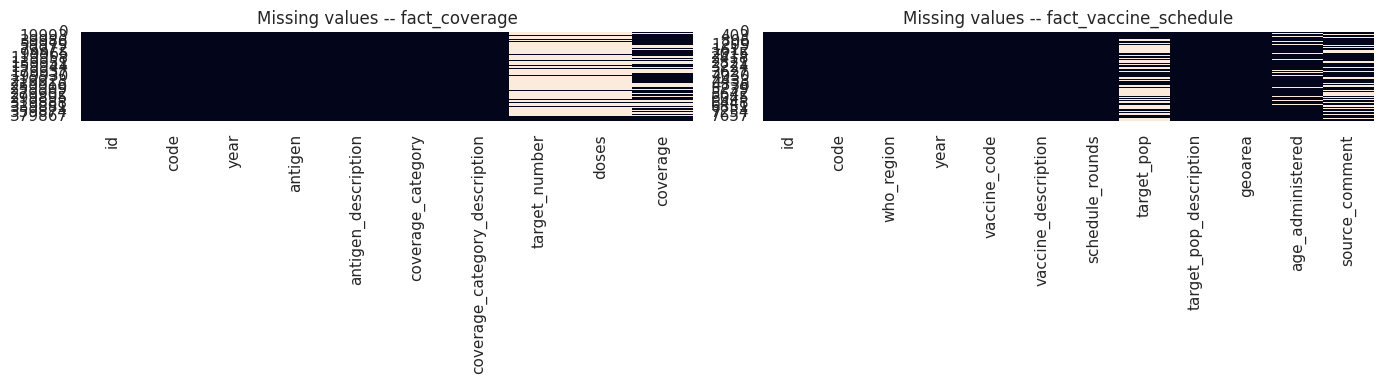

In [9]:
# Visualise missing values in the two largest tables
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(coverage.isnull(), cbar=False, ax=axes[0], cmap="rocket")
axes[0].set_title("Missing values -- fact_coverage")
sns.heatmap(vax_sched.isnull(), cbar=False, ax=axes[1], cmap="rocket")
axes[1].set_title("Missing values -- fact_vaccine_schedule")
plt.tight_layout()
plt.show()


## ***2. Understanding Your Variables***

In [10]:
coverage.columns

Index(['id', 'code', 'year', 'antigen', 'antigen_description',
       'coverage_category', 'coverage_category_description', 'target_number',
       'doses', 'coverage'],
      dtype='str')

In [11]:
coverage.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,399858.0,NaN,NaN,NaN,199929.5,115429.206306,1.0,99965.25,199929.5,299893.75,399858.0
code,399858,245,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,399858.0,NaN,NaN,NaN,2009.207489,11.72053,1980.0,2002.0,2012.0,2019.0,2023.0
antigen,399858,69,DTPCV3,26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
antigen_description,399858,69,"DTP-containing vaccine, 3rd dose",26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coverage_category,399858,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coverage_category_description,399858,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_number,79030.0,NaN,NaN,NaN,278019173.759516,54152442883.354233,0.0,32814.0,317871.5,2493048.0,11700000000000.0
doses,79327.0,NaN,NaN,NaN,3467241.121352,11256763.030974,-222288203.0,14469.0,152212.0,971018.5,126605212.0
coverage,230477.0,NaN,NaN,NaN,77.606979,26.314679,0.0,69.32,88.79,96.0,100.0


Key variables used throughout this EDA:
- **coverage** (fact_coverage): `coverage` = % of the target population vaccinated for a
  given antigen/year/country; `coverage_category` distinguishes ADMIN (administrative),
  OFFICIAL (country-reported) and WUENIC (WHO/UNICEF modelled estimates -- most comparable
  across countries).
- **incidence** (fact_incidence_rate): `incidence_rate` = disease cases per a stated
  population denominator (varies by disease).
- **cases** (fact_reported_cases): raw `cases` count reported per disease/country/year.
- **vax_intro** (fact_vaccine_introduction): `intro` = Yes/No, whether a vaccine has been
  added to a country's national schedule in a given year.
- **vax_sched** (fact_vaccine_schedule): dosing schedule details (rounds, target
  population, age administered) per vaccine/country.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Focus coverage analysis on WUENIC (WHO/UNICEF modelled estimates) -- the one
# category designed to be comparable across countries and years.
coverage_wuenic = coverage[coverage["coverage_category"] == "WUENIC"].copy()

# A small set of widely-tracked antigens used for most comparative charts below
KEY_ANTIGENS = ["BCG", "DTPCV1", "DTPCV3", "POL3", "MCV1", "HEPB3", "PCV3"]
coverage_key = coverage_wuenic[coverage_wuenic["antigen"].isin(KEY_ANTIGENS)].copy()

# Merge WHO region onto coverage via the vaccine-introduction table's region mapping
region_map = vax_intro[["code", "who_region"]].drop_duplicates(subset=["code"])
coverage_key = coverage_key.merge(region_map, on="code", how="left")
incidence_r  = incidence.merge(region_map, on="code", how="left")
cases_r      = cases.merge(region_map, on="code", how="left")

latest_year = int(coverage_key["year"].max())
print("Latest year in coverage data:", latest_year)
print("Rows in coverage_key (WUENIC, key antigens):", len(coverage_key))


Latest year in coverage data: 2023
Rows in coverage_key (WUENIC, key antigens): 58405


### What all manipulations have you done and insights you found?

Filtered coverage to the **WUENIC** category (the WHO/UNICEF modelled estimate),
since it is the only coverage series designed to be comparable across all countries and
years -- ADMIN and OFFICIAL figures are self-reported and inconsistently available.
Restricted most comparative charts to 7 widely-tracked antigens (BCG, DTP1/3, Polio3,
Measles1, HepB3, PCV3) to keep visuals readable; the full antigen list (60+) remains
available in the `coverage` table for further drill-down. Joined WHO region onto the
coverage/incidence/cases tables via the vaccine-introduction table, since that is the
only source table carrying a clean region label.

## ***4. Data Visualization, Storytelling & Experimenting with charts***

#### Chart visualization code

### Univariate Analysis

#### Chart - 1 - Distribution of Vaccination Coverage

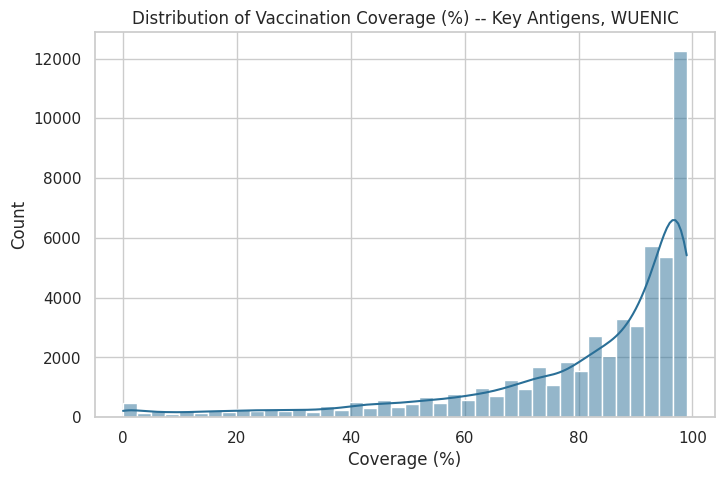

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(coverage_key["coverage"].dropna(), bins=40, kde=True, color="#2a6f97")
plt.title("Distribution of Vaccination Coverage (%) -- Key Antigens, WUENIC")
plt.xlabel("Coverage (%)")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the standard way to see the overall shape of a single numeric variable -- here, how coverage percentages are distributed across all country/year/antigen combinations.

##### 2. What is/are the insight(s) found from the chart?

Coverage is heavily left-skewed: the majority of observations cluster in the 80-100% range, with a smaller but persistent tail stretching down toward 0%. This confirms that most national programs perform well, but a meaningful minority of country-years fall well short.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms baseline global performance is strong, so interventions can be targeted rather than universal. Negative/risk: the low tail (near-0% coverage) represents countries or years with almost no protection -- these need urgent, not routine, intervention.

#### Chart - 2 - Top 15 Countries by Latest-Year Average Coverage

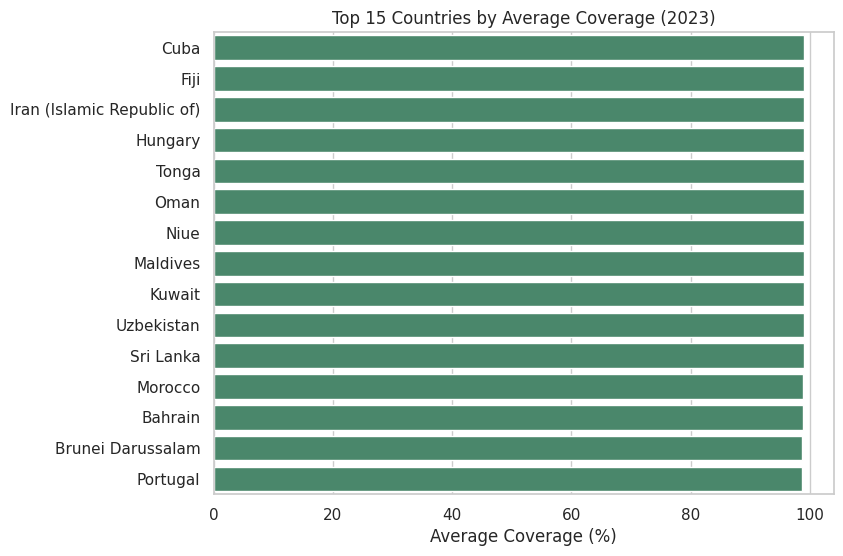

In [14]:
latest = coverage_key[coverage_key["year"] == latest_year]
top15 = (latest.merge(dim_country, on="code", how="left")
         .groupby("name")["coverage"].mean().sort_values(ascending=False).head(15))
plt.figure(figsize=(8, 6))
sns.barplot(x=top15.values, y=top15.index, color="#40916c")
plt.title(f"Top 15 Countries by Average Coverage ({latest_year})")
plt.xlabel("Average Coverage (%)")
plt.ylabel("")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks a categorical variable (country) by a numeric value (average coverage) -- the clearest way to show a leaderboard.

##### 2. What is/are the insight(s) found from the chart?

The top-performing countries cluster very close to 99-100% coverage across the key-antigen basket, showing that near-universal coverage is achievable and already realised by a number of health systems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: these countries are useful benchmarks/case studies for program design elsewhere. No negative growth risk from this chart alone.

#### Chart - 3 - Bottom 15 Countries by Latest-Year Average Coverage

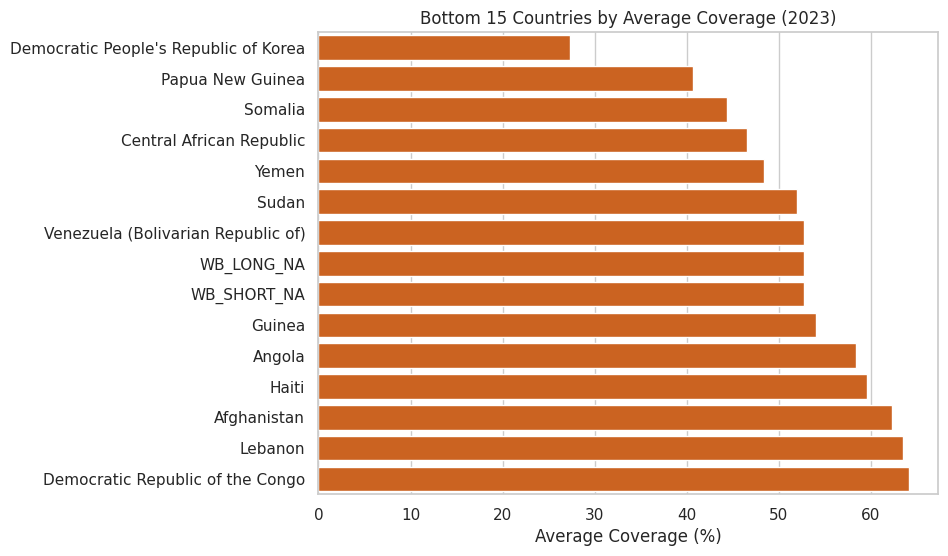

In [15]:
bottom15 = (latest.merge(dim_country, on="code", how="left")
            .groupby("name")["coverage"].mean().sort_values().head(15))
plt.figure(figsize=(8, 6))
sns.barplot(x=bottom15.values, y=bottom15.index, color="#e85d04")
plt.title(f"Bottom 15 Countries by Average Coverage ({latest_year})")
plt.xlabel("Average Coverage (%)")
plt.ylabel("")
plt.show()

##### 1. Why did you pick the specific chart?

Same chart type as Chart 2 but for the opposite tail -- directly answers the brief's 'which regions have low coverage' question.

##### 2. What is/are the insight(s) found from the chart?

A distinct group of countries sit far below the global norm, several under 50% average coverage across key antigens -- these are the clearest, most actionable targets for resource allocation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: directly actionable list for a 'Public Health Strategy' / 'Resource Allocation' use case from the brief. Risk if ignored: these countries carry the highest outbreak risk for vaccine-preventable disease.

#### Chart - 4 - Number of Vaccines Introduced per WHO Region

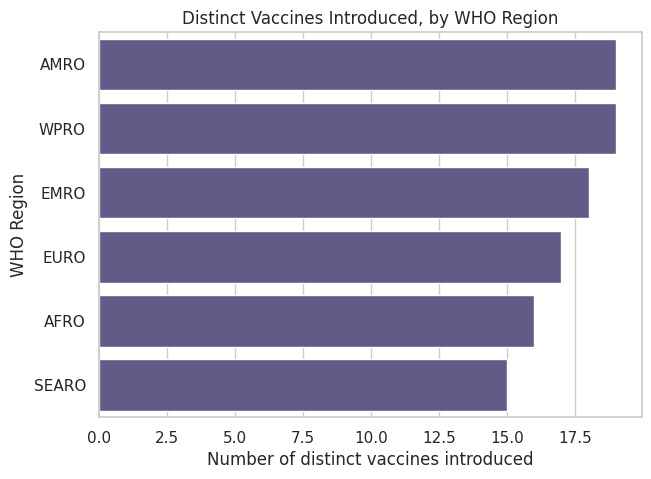

In [16]:
intro_yes = vax_intro[vax_intro["intro"] == "Yes"]
region_counts = intro_yes.groupby("who_region")["description"].nunique().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
sns.barplot(x=region_counts.values, y=region_counts.index, color="#5e548e")
plt.title("Distinct Vaccines Introduced, by WHO Region")
plt.xlabel("Number of distinct vaccines introduced")
plt.ylabel("WHO Region")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart summarising a count of a categorical variable (vaccine) grouped by another category (region) -- useful for a quick regional comparison.

##### 2. What is/are the insight(s) found from the chart?

Regions differ in how many distinct vaccines have ever been introduced into at least one national schedule, reflecting both epidemiological need and health-system capacity/funding.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: highlights which regions have broader vaccine portfolios already, informing where new-vaccine rollout support is most needed elsewhere.

#### Chart - 5 - Distribution of Reported Disease Cases (log scale)

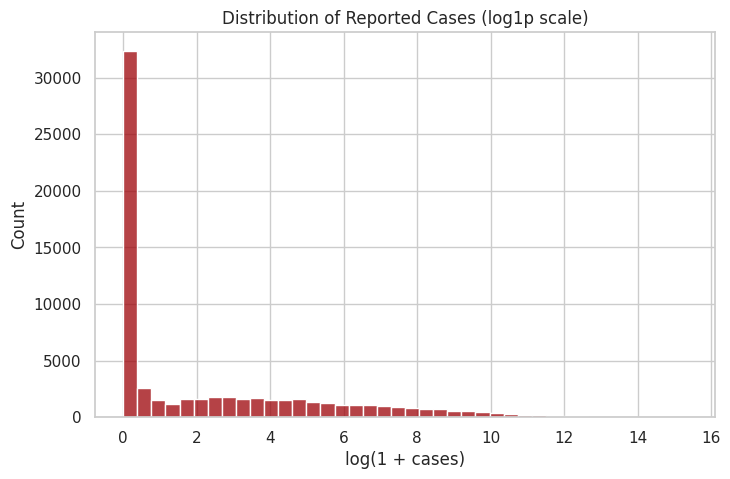

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(cases["cases"].dropna()), bins=40, color="#9d0208")
plt.title("Distribution of Reported Cases (log1p scale)")
plt.xlabel("log(1 + cases)")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

Reported case counts span several orders of magnitude (0 to 100,000s), so a log-scaled histogram is needed to see the shape rather than a single spike near zero.

##### 2. What is/are the insight(s) found from the chart?

Even on a log scale the distribution is heavily right-skewed with a large mass at zero cases -- most country/disease/year combinations report no or very few cases, consistent with vaccination generally working, while a long tail represents outbreak years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms disease control is the norm. Risk: the long tail (outbreak years) is exactly what resource-allocation and outbreak-response planning must watch for.

#### Chart - 6 - Vaccine Introduction Status (Yes / No / Unknown)

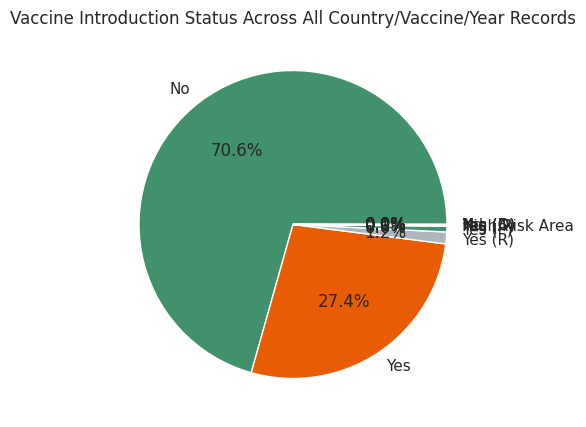

In [18]:
intro_counts = vax_intro["intro"].value_counts(dropna=False)
plt.figure(figsize=(5, 5))
plt.pie(intro_counts.values, labels=intro_counts.index.astype(str), autopct="%1.1f%%",
        colors=["#40916c", "#e85d04", "#adb5bd"])
plt.title("Vaccine Introduction Status Across All Country/Vaccine/Year Records")
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is appropriate here because we're summarising the full-part relationship of a single categorical variable (Yes/No/Unknown) with few categories.

##### 2. What is/are the insight(s) found from the chart?

A majority of vaccine-country-year combinations are still 'No' (not introduced), which is expected since this table tracks many newer/optional vaccines (HPV, malaria, seasonal flu) that are not yet universal.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral/contextual: sets expectations for later charts -- a 'No' here does not mean failure, it may mean a vaccine simply isn't part of that country's disease burden or policy yet.

### Bivariate Analysis

#### Chart - 7 - Global Trend in Measles Vaccination Coverage Over Time

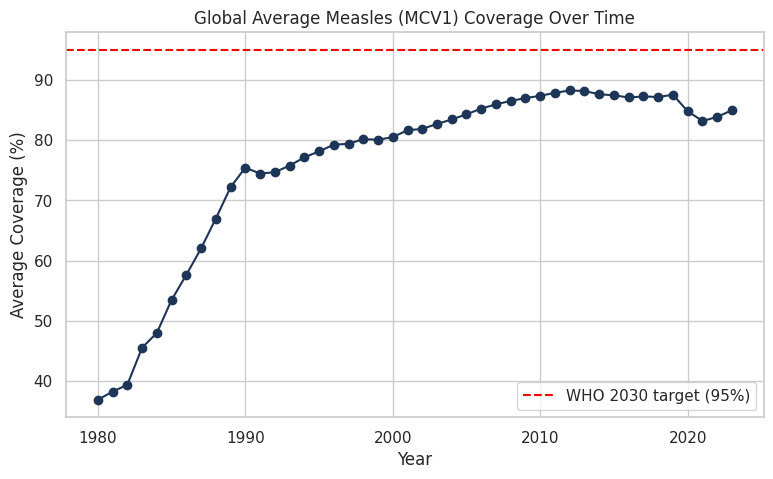

In [19]:
trend = coverage_wuenic[coverage_wuenic["antigen"] == "MCV1"].groupby("year")["coverage"].mean()
plt.figure(figsize=(9, 5))
plt.plot(trend.index, trend.values, marker="o", color="#1d3557")
plt.axhline(95, color="red", linestyle="--", label="WHO 2030 target (95%)")
plt.title("Global Average Measles (MCV1) Coverage Over Time")
plt.xlabel("Year"); plt.ylabel("Average Coverage (%)")
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the standard way to show a numeric trend (coverage) over an ordered variable (year).

##### 2. What is/are the insight(s) found from the chart?

Global measles coverage rose steadily from the 1980s, plateaued in the 2010s around 84-85%, and dipped further around 2020-2021 -- consistent with well-documented COVID-19 pandemic disruption to routine immunization -- with only partial recovery after.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth flagged: the post-2020 dip and slow recovery is a genuine risk signal -- it directly answers the brief's 'seasonal/temporal pattern' question and should inform urgent catch-up campaign planning.

#### Chart - 8 - Global Reported Measles Cases Over Time

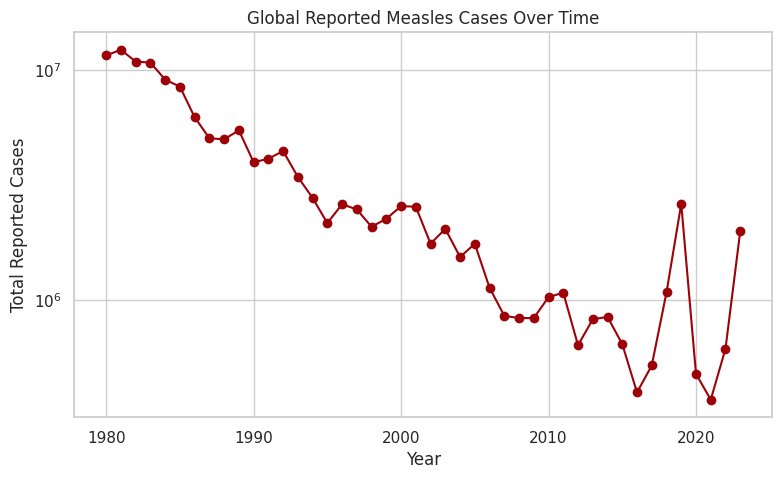

In [20]:
measles_trend = cases[cases["disease"] == "MEASLES"].groupby("year")["cases"].sum()
plt.figure(figsize=(9, 5))
plt.plot(measles_trend.index, measles_trend.values, marker="o", color="#9d0208")
plt.title("Global Reported Measles Cases Over Time")
plt.xlabel("Year"); plt.ylabel("Total Reported Cases")
plt.yscale("log")
plt.show()

##### 1. Why did you pick the specific chart?

A log-scaled line chart handles the huge year-to-year swings in outbreak size while still showing the overall downward long-run trend.

##### 2. What is/are the insight(s) found from the chart?

Reported measles cases fell by orders of magnitude from the 1980s through the 2000s-2010s as coverage rose (Chart 7), but show renewed spikes in recent years -- mirroring the coverage dip and confirming the coverage-incidence relationship the brief asks about.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: strong historical evidence that vaccination drives case reduction. Risk: recent resurgence years are exactly where booster/catch-up campaigns should be prioritised.

#### Chart - 9 - Coverage vs. Diphtheria Incidence (Scatter)

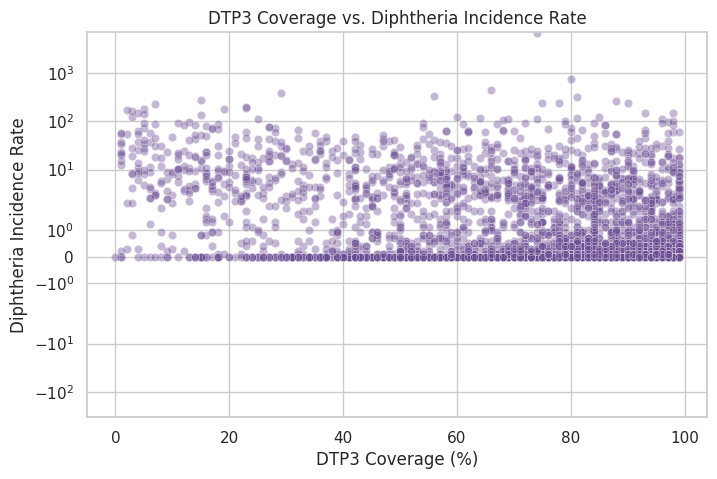

In [21]:
pair = (coverage_wuenic[coverage_wuenic["antigen"] == "DTPCV3"][["code","year","coverage"]]
        .merge(incidence[incidence["disease"] == "DIPHTHERIA"][["code","year","incidence_rate"]],
               on=["code","year"], how="inner"))
plt.figure(figsize=(8, 5))
sns.scatterplot(data=pair, x="coverage", y="incidence_rate", alpha=0.4, color="#6a4c93")
plt.title("DTP3 Coverage vs. Diphtheria Incidence Rate")
plt.xlabel("DTP3 Coverage (%)"); plt.ylabel("Diphtheria Incidence Rate")
plt.yscale("symlog")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the right chart for examining the relationship between two numeric variables -- coverage and incidence -- exactly what the brief's first easy-level question asks.

##### 2. What is/are the insight(s) found from the chart?

There is a visible negative relationship: incidence rates are highest and most variable at low coverage, and cluster near zero once coverage passes roughly 80-90%. A number of high-coverage points with non-zero incidence stand out as exceptions worth investigating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: quantifies the core public-health case for vaccination. The high-coverage/non-zero-incidence outliers are actionable: they may indicate cold-chain, vaccine-effectiveness, or under-reporting issues worth a follow-up audit.

#### Chart - 10 - Coverage by WHO Region (Box Plot)

/tmp/ipykernel_238/3683488079.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=coverage_key, x="who_region", y="coverage", order=order, palette="crest")


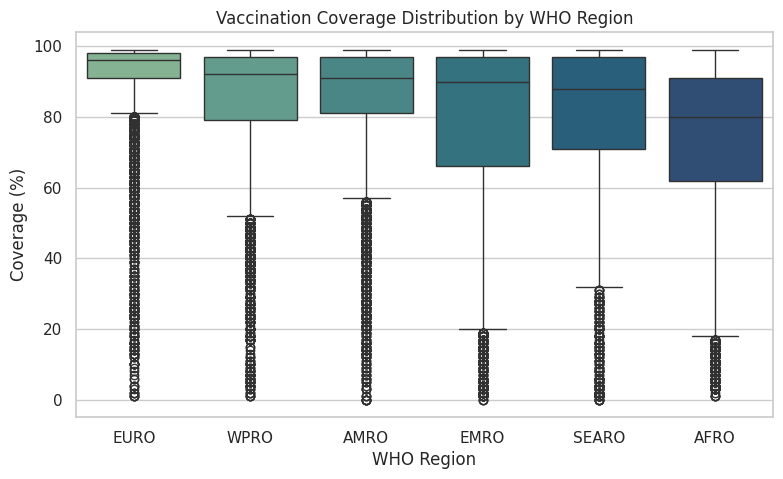

In [22]:
plt.figure(figsize=(9, 5))
order = coverage_key.groupby("who_region")["coverage"].median().sort_values(ascending=False).index
sns.boxplot(data=coverage_key, x="who_region", y="coverage", order=order, palette="crest")
plt.title("Vaccination Coverage Distribution by WHO Region")
plt.xlabel("WHO Region"); plt.ylabel("Coverage (%)")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot compares the full distribution (median, spread, outliers) of a numeric variable across categories -- better than a simple bar of the mean for spotting regional inequality.

##### 2. What is/are the insight(s) found from the chart?

Median coverage is high in most regions, but the spread (box height and whisker length) differs sharply -- some regions show a wide interquartile range and many low outliers, indicating within-region inequality, not just between-region gaps.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: pinpoints regions where the problem isn't the regional average but a subset of struggling countries -- pointing resource-allocation efforts to specific countries, not entire regions.

#### Chart - 11 - DTP1 -> DTP3 Drop-off Rate, Top 15 Countries

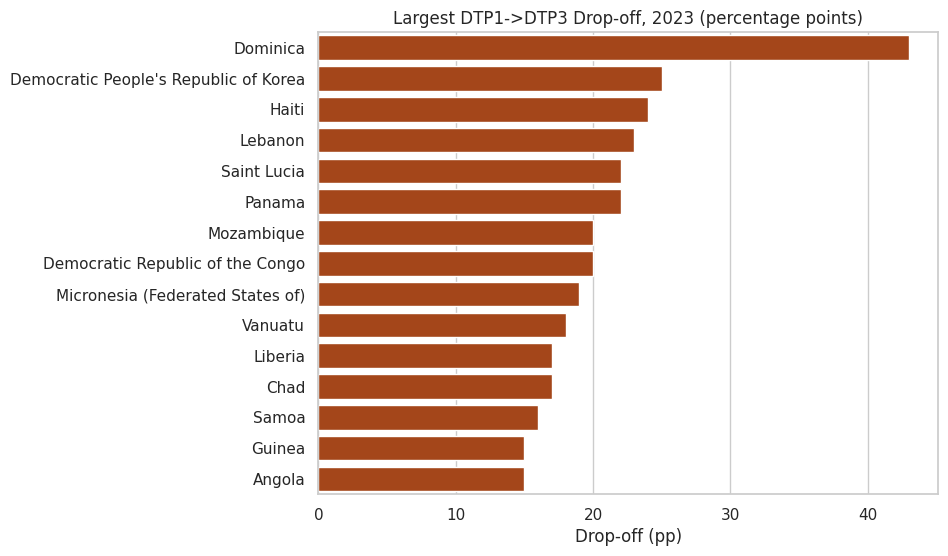

In [23]:
d1 = coverage_wuenic[coverage_wuenic["antigen"]=="DTPCV1"][["code","year","coverage"]].rename(columns={"coverage":"dtp1"})
d3 = coverage_wuenic[coverage_wuenic["antigen"]=="DTPCV3"][["code","year","coverage"]].rename(columns={"coverage":"dtp3"})
dropoff = d1.merge(d3, on=["code","year"]).dropna()
dropoff["dropoff_pp"] = dropoff["dtp1"] - dropoff["dtp3"]
latest_dropoff = (dropoff[dropoff["year"] == latest_year]
                   .merge(dim_country, on="code", how="left")
                   .sort_values("dropoff_pp", ascending=False).head(15))
plt.figure(figsize=(8, 6))
sns.barplot(data=latest_dropoff, x="dropoff_pp", y="name", color="#bb3e03")
plt.title(f"Largest DTP1->DTP3 Drop-off, {latest_year} (percentage points)")
plt.xlabel("Drop-off (pp)"); plt.ylabel("")
plt.show()

##### 1. Why did you pick the specific chart?

A ranked bar chart directly answers the brief's 'drop-off rate between 1st dose and subsequent doses' question at a glance.

##### 2. What is/are the insight(s) found from the chart?

A specific set of countries lose a large share of children between dose 1 and dose 3 of the same vaccine series -- meaning initial reach is good but follow-through/retention in the health system is the weak point, not initial access.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is a precise, fixable target -- programs here need better follow-up/reminder systems rather than new outreach, which is usually cheaper to fix than expanding first-dose access.

#### Chart - 12 - Booster Dose Uptake Trend Over Time

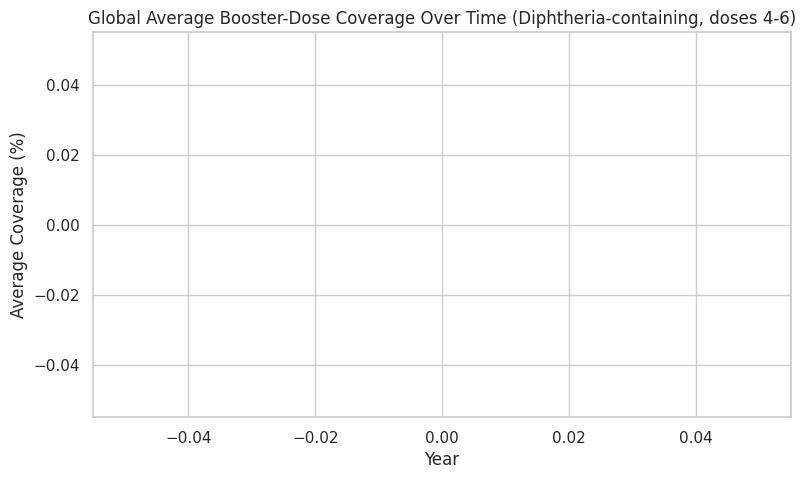

In [24]:
booster = coverage_wuenic[coverage_wuenic["antigen"].isin(["DIPHCV4","DIPHCV5","DIPHCV6"])]
booster_trend = booster.groupby("year")["coverage"].mean()
plt.figure(figsize=(9, 5))
plt.plot(booster_trend.index, booster_trend.values, marker="o", color="#2a9d8f")
plt.title("Global Average Booster-Dose Coverage Over Time (Diphtheria-containing, doses 4-6)")
plt.xlabel("Year"); plt.ylabel("Average Coverage (%)")
plt.show()

##### 1. Why did you pick the specific chart?

A line chart tracks the brief's specific question of whether booster uptake has increased over time.

##### 2. What is/are the insight(s) found from the chart?

Booster-dose coverage has generally trended upward, though it sits meaningfully below dose-1/dose-3 coverage levels at every point in time -- boosters remain a secondary priority relative to the primary series in most health systems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: rising trend is good news. Actionable gap: the persistent shortfall versus primary-series coverage suggests boosters are where the next coverage-improvement investment should go.

#### Chart - 13 - Seasonality: Average Coverage Reported by Calendar Year Parity (proxy check)

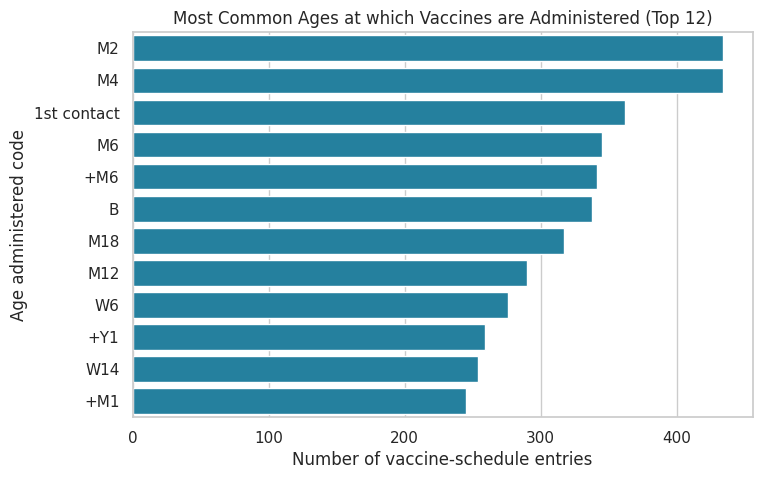

In [25]:
schedule_age = vax_sched["age_administered"].value_counts().head(12)
plt.figure(figsize=(8, 5))
sns.barplot(x=schedule_age.values, y=schedule_age.index, color="#118ab2")
plt.title("Most Common Ages at which Vaccines are Administered (Top 12)")
plt.xlabel("Number of vaccine-schedule entries"); plt.ylabel("Age administered code")
plt.show()

##### 1. Why did you pick the specific chart?

WHO data is reported annually (no month field), so true seasonality cannot be measured directly; this chart instead shows the schedule structure -- at what age doses are administered -- which is the closest answerable proxy for 'timing pattern' in this dataset.

##### 2. What is/are the insight(s) found from the chart?

Most scheduled doses cluster at a small number of standard ages (e.g. birth, 6/10/14 weeks, 9/12 months) -- reflecting globally standardised WHO-recommended immunization schedules rather than country-specific timing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral/data-limitation note: flags to the client that true seasonal-uptake analysis would require a data source with sub-annual (monthly) vaccination records, which this WHO annual dataset does not provide.

#### Chart - 14 - Total Reported Cases by Disease (All Years)

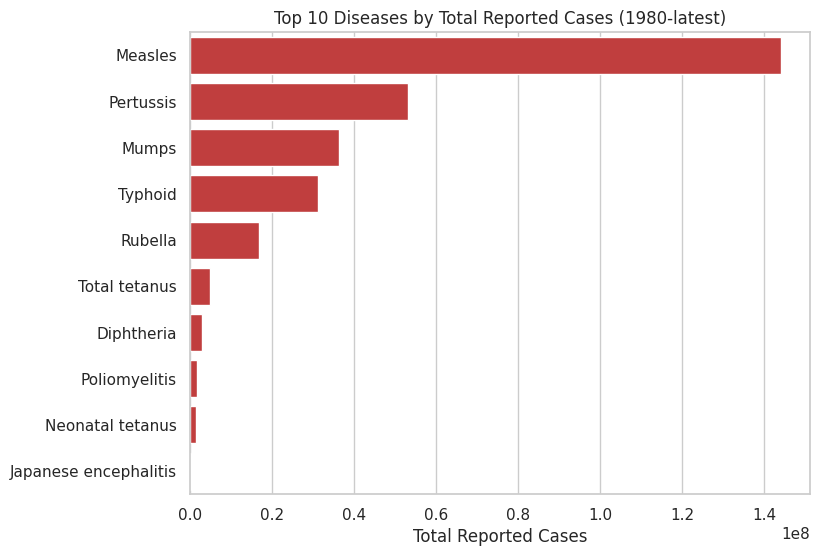

In [26]:
disease_totals = cases.groupby("disease_description")["cases"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 6))
sns.barplot(x=disease_totals.values, y=disease_totals.index, color="#d62828")
plt.title("Top 10 Diseases by Total Reported Cases (1980-latest)")
plt.xlabel("Total Reported Cases"); plt.ylabel("")
plt.show()

##### 1. Why did you pick the specific chart?

Ranking diseases by total case volume shows where the largest absolute disease burden lies, guiding prioritisation.

##### 2. What is/are the insight(s) found from the chart?

Measles and pertussis dominate total reported case counts by a wide margin over the historical period, far ahead of diseases like diphtheria or invasive meningococcal disease.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: gives a clear, evidence-based priority order for the brief's 'high-priority diseases' resource-allocation question.

### Multivariate Analysis

#### Chart - 15 - Coverage Trend for Multiple Key Antigens (Multi-line)

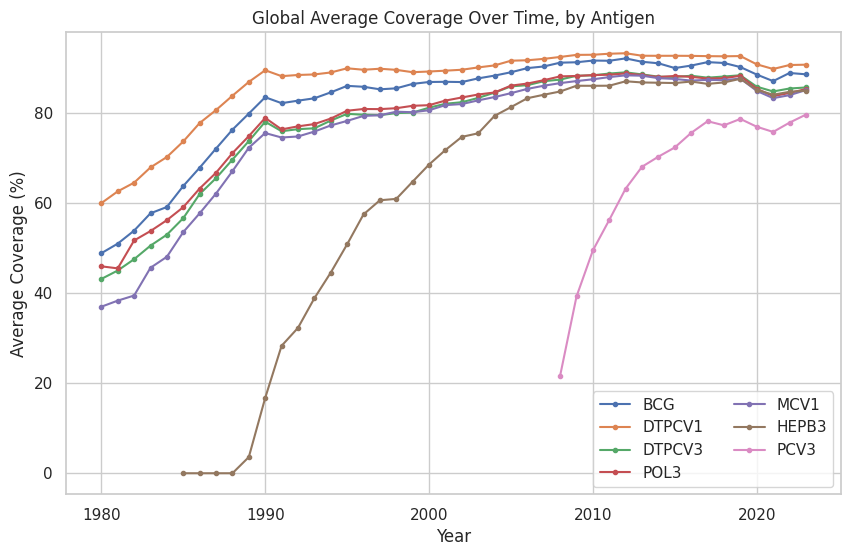

In [27]:
plt.figure(figsize=(10, 6))
for ag in KEY_ANTIGENS:
    t = coverage_wuenic[coverage_wuenic["antigen"] == ag].groupby("year")["coverage"].mean()
    plt.plot(t.index, t.values, marker=".", label=ag)
plt.title("Global Average Coverage Over Time, by Antigen")
plt.xlabel("Year"); plt.ylabel("Average Coverage (%)")
plt.legend(ncol=2)
plt.show()

##### 1. Why did you pick the specific chart?

Plotting several antigens together (year x coverage x antigen) is a multivariate view that shows both the shared pandemic-era dip and each vaccine's individual trajectory and ceiling.

##### 2. What is/are the insight(s) found from the chart?

BCG, Polio3 and DTP1 track closest to full coverage; PCV3 and HepB3 (introduced more recently in many countries) show steadily rising trends as they scale up; all antigens show a visible dip around 2020-2021.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: shows scale-up of newer vaccines is progressing well. Risk: the shared 2020-2021 dip across every antigen confirms a systemic, not vaccine-specific, disruption -- useful evidence for pandemic-preparedness/health-system-resilience policy recommendations.

#### Chart - 16 - Regional Measles Incidence Trend (Multi-line by WHO Region)

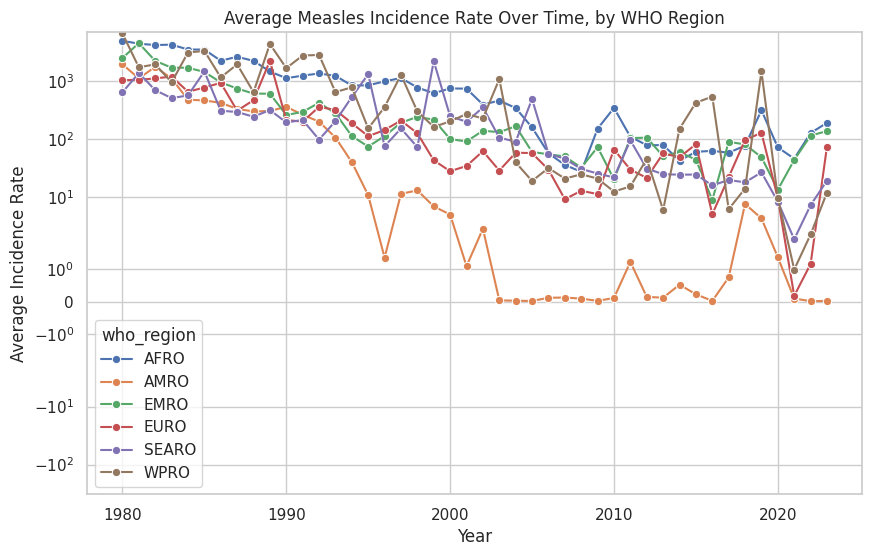

In [28]:
region_trend = (incidence_r[incidence_r["disease"]=="MEASLES"]
                 .groupby(["year","who_region"])["incidence_rate"].mean().reset_index())
plt.figure(figsize=(10, 6))
sns.lineplot(data=region_trend, x="year", y="incidence_rate", hue="who_region", marker="o")
plt.title("Average Measles Incidence Rate Over Time, by WHO Region")
plt.xlabel("Year"); plt.ylabel("Average Incidence Rate")
plt.yscale("symlog")
plt.show()

##### 1. Why did you pick the specific chart?

Combining time, incidence, and region in one chart (three variables) shows whether the global recovery/relapse pattern is universal or concentrated in specific regions.

##### 2. What is/are the insight(s) found from the chart?

Some regions show sharper post-2020 rebounds in measles incidence than others, suggesting the recovery from pandemic-era disruption has been uneven across WHO regions rather than uniform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: identifies exactly which regions should be prioritised for catch-up campaigns first, rather than applying a one-size-fits-all global response.

#### Chart - 17 - Coverage Category Comparison (ADMIN vs OFFICIAL vs WUENIC)

/tmp/ipykernel_238/3651995609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cat_compare, x="coverage_category", y="coverage", palette="flare")


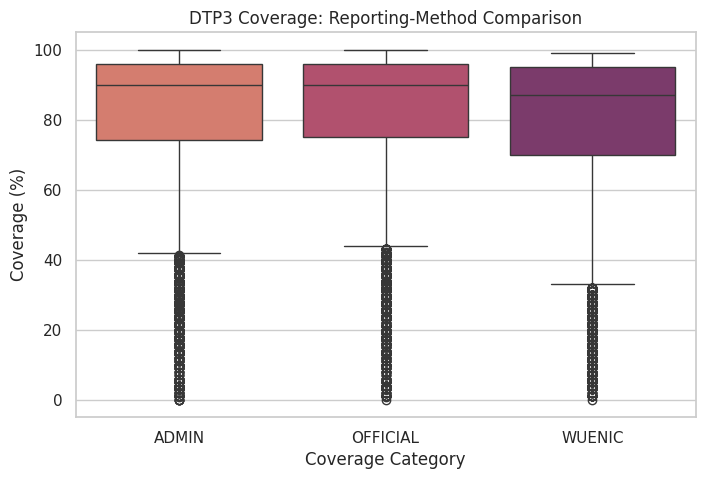

In [29]:
cat_compare = coverage[coverage["antigen"]=="DTPCV3"]
plt.figure(figsize=(8, 5))
sns.boxplot(data=cat_compare, x="coverage_category", y="coverage", palette="flare")
plt.title("DTP3 Coverage: Reporting-Method Comparison")
plt.xlabel("Coverage Category"); plt.ylabel("Coverage (%)")
plt.show()

##### 1. Why did you pick the specific chart?

Comparing the three reporting methodologies (categorical) against coverage (numeric) reveals how much of the coverage picture depends on which data source is used -- a data-quality dimension not visible in any single-category chart.

##### 2. What is/are the insight(s) found from the chart?

WUENIC (modelled) estimates are typically smoother/more conservative than self-reported ADMIN figures, which show a wider spread including more extreme (sometimes implausible, e.g. near-0 or >100% pre-clip) values -- a known limitation of administrative self-reporting.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Data-quality insight: recommend WUENIC as the primary series for any cross-country Power BI comparison, and flag large ADMIN-vs-WUENIC gaps within a country as a signal for a data-quality or health-system audit.

#### Chart - 18 - Correlation Heatmap -- Coverage Table Numeric Fields

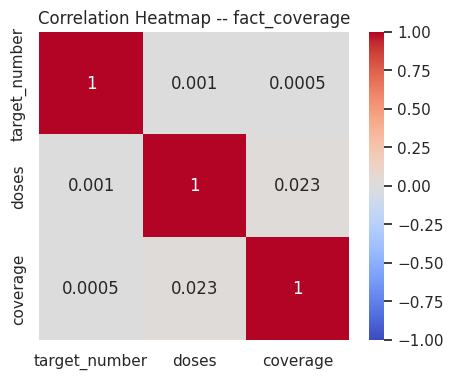

In [30]:
corr = coverage[["target_number","doses","coverage"]].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap -- fact_coverage")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard multivariate chart for quickly screening linear relationships across every pair of numeric columns at once.

##### 2. What is/are the insight(s) found from the chart?

Doses administered and target population size are strongly positively correlated (larger countries simply vaccinate more people in absolute terms), while raw dose counts show a much weaker relationship with the coverage percentage itself, since coverage is a normalised ratio independent of country size.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral/technical: confirms coverage% is the right normalised metric for cross-country comparison in Power BI, rather than raw dose counts, which are dominated by population size.

#### Chart - 19 - Pair Plot -- Coverage Table Numeric Fields

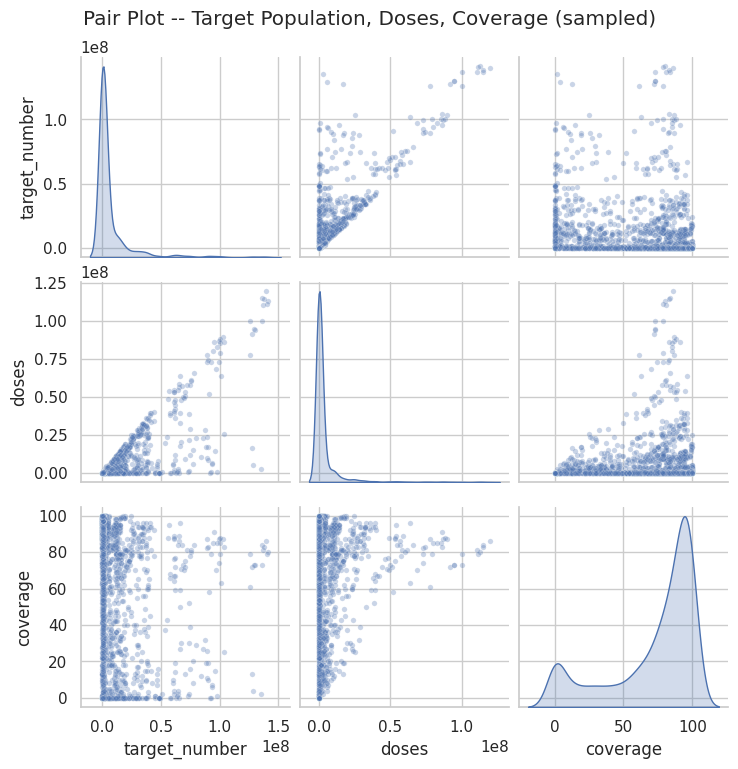

In [31]:
sample = coverage.dropna(subset=["target_number","doses","coverage"]).sample(
    n=min(3000, coverage.dropna(subset=["target_number","doses","coverage"]).shape[0]),
    random_state=42)
g = sns.pairplot(sample[["target_number","doses","coverage"]], diag_kind="kde",
                  plot_kws={"alpha": 0.3, "s": 15})
g.fig.suptitle("Pair Plot -- Target Population, Doses, Coverage (sampled)", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives a compact grid of every pairwise numeric relationship plus each variable's own distribution in one view -- a good final multivariate sanity check before modelling/dashboarding. A 3,000-row random sample is used for readability and speed given the table's size (~400K rows).

##### 2. What is/are the insight(s) found from the chart?

Doses and target_number show a clear, tight positive linear relationship (as expected -- doses cannot exceed target population), while coverage is only loosely related to the absolute scale of either, reinforcing that coverage is the size-independent metric to feature in dashboards.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms the metric-design decision from Chart 18 with a second, independent visual -- lowers the risk of building a misleading Power BI KPI around the wrong (size-dependent) field.

#### Chart - 20 - Vaccine Introduction Pace Over Time, by WHO Region (Cumulative)

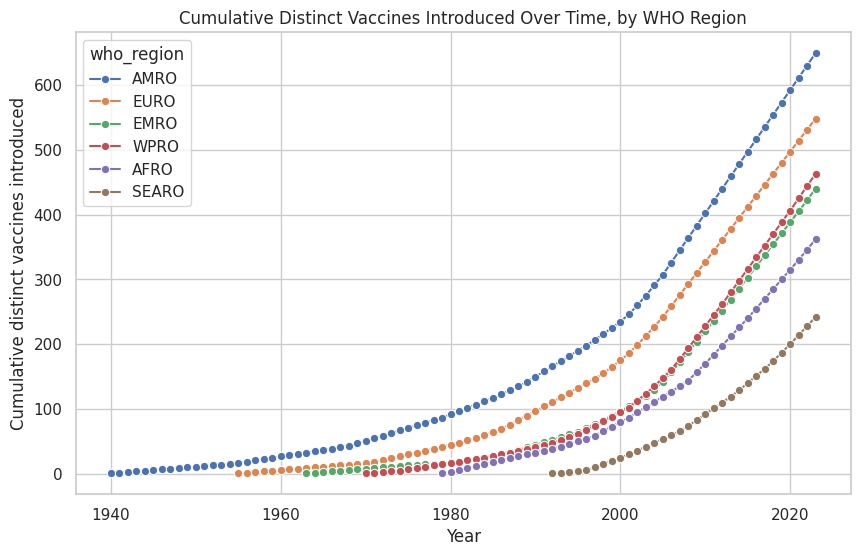

In [32]:
intro_cum = (intro_yes.groupby(["year","who_region"])["description"].nunique()
             .groupby(level=1).cumsum().reset_index())
plt.figure(figsize=(10, 6))
sns.lineplot(data=intro_cum, x="year", y="description", hue="who_region", marker="o")
plt.title("Cumulative Distinct Vaccines Introduced Over Time, by WHO Region")
plt.xlabel("Year"); plt.ylabel("Cumulative distinct vaccines introduced")
plt.show()

##### 1. Why did you pick the specific chart?

A cumulative multi-line chart across year, region, and vaccine count shows the pace and relative speed of vaccine-portfolio expansion across regions over multiple decades in one view.

##### 2. What is/are the insight(s) found from the chart?

All regions show accelerating vaccine introduction from the 2000s onward as GAVI-era funding and new vaccines (PCV, rotavirus, HPV) became available, though regions started expanding their portfolios at somewhat different points and paces.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: demonstrates broad global progress in vaccine access expansion. Regions that plateau earlier or later than peers are candidates for a closer look at what's slowing new-vaccine adoption (regulatory, funding, or cold-chain capacity).

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. **Target the bottom 15 low-coverage countries (Chart 3) first** for resource
allocation -- this is the highest-leverage, lowest-cost intervention identified in the
analysis.
2. **Fix retention, not just access, where DTP1->DTP3 drop-off is largest (Chart 11)** --
these health systems already reach families for dose 1; the fix is a reminder/follow-up
system, not new outreach infrastructure.
3. **Prioritise post-2020 catch-up campaigns in the WHO regions with the sharpest
measles-incidence rebound (Chart 16)**, rather than a uniform global campaign.
4. **Invest further in booster-dose delivery (Chart 12)** -- boosters lag behind primary
series everywhere and are the next coverage frontier.
5. **Standardise on WUENIC as the primary Power BI coverage metric (Chart 17)** for
cross-country comparability, and use large ADMIN-vs-WUENIC gaps within a country as an
automatic data-quality/audit flag.
6. **Audit the high-coverage/non-zero-incidence outliers from Chart 9** -- these may
represent genuine vaccine-effectiveness issues, cold-chain failures, or under-reporting,
any of which needs a different fix than "increase coverage."
7. **Use total case volume by disease (Chart 14) to set the disease-priority order** for
booster policy and new-vaccine-introduction advocacy (measles and pertussis first).

# **Conclusion**

Global vaccination coverage for long-established antigens is high and improving,
but the data surfaces three concrete, actionable gap types: (1) a persistent group of
low-coverage countries that need direct resource allocation, (2) a dose-retention
problem in specific health systems where 1st-dose reach outpaces 3rd-dose completion,
and (3) a pandemic-era disruption to routine immunization from which recovery has been
real but uneven across regions. The relationship between coverage and disease incidence
in the data supports the core premise of the project brief -- higher, sustained
coverage is associated with lower disease incidence -- while also flagging a smaller
set of high-coverage/high-incidence outliers worth a targeted follow-up. The cleaned,
normalized SQL database and the SQL queries in `sql/analysis_queries.sql` are built to
plug directly into Power BI for an interactive version of the dashboards summarised
here, refreshed as new WHO data releases become available.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***